In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

In [119]:
primary = pd.read_csv(r'non-asher-cleaned\number-of-govt-primary-schools-non-functional-2021-numbers-kpk-pakistan.csv', encoding='latin1')
middle = pd.read_csv(r'non-asher-cleaned\number-of-govt-middle-schools-non-functional-2021-numbers-kpk-pakistan.csv', encoding='latin1')
ind = pd.read_csv(r"non-asher-cleaned\key-indicators-of-education-in-pakistan.csv", encoding='latin1')

Objective 1: Measure the burden of non-functional schools by level (Primary vs Middle) and gender (Male vs Female) across KPK districts in 2021.

Primary dataset

In [120]:
primary.columns

Index(['ï»¿District', 'Male', 'Female', 'Total'], dtype='object')

In [121]:
primary.rename(columns={"ï»¿District": "District"}, inplace=True)

In [122]:
primary.columns

Index(['District', 'Male', 'Female', 'Total'], dtype='object')

In [123]:
# STEP 2.1: Clean primary

# Drop empty District rows and force a proper copy
primary = primary.dropna(subset=['District']).copy()

# Ensure numeric types (SAFE assignment)
for col in ['Male', 'Female', 'Total']:
    primary.loc[:, col] = pd.to_numeric(primary[col], errors='coerce')

# Check if Total == Male + Female (SAFE assignment)
primary.loc[:, 'Total_check'] = primary['Male'] + primary['Female']

mismatch_primary = primary[primary['Total'] != primary['Total_check']]


In [124]:
# Dervied columns
primary['Level'] = 'Primary'
primary['female_share'] = primary['Female'] / primary['Total']
primary['male_share'] = primary['Male'] / primary['Total']

middle dataset

In [125]:
middle.rename(columns={"ï»¿District": "District"}, inplace=True)

In [126]:
# STEP 2.2: Clean middle

for col in ['Male', 'Female', 'Total']:
    middle[col] = pd.to_numeric(middle[col], errors='coerce')

middle['Total_check'] = middle['Male'] + middle['Female']
mismatch_middle = middle[middle['Total'] != middle['Total_check']]

mismatch_middle

,District,Male,Female,Total,Total_check


In [127]:
# Derived columns
middle['Level'] = 'Middle'
middle['female_share'] = middle['Female'] / middle['Total']
middle['male_share'] = middle['Male'] / middle['Total']

big-picture KPK summary

In [128]:
# STEP 3.1: Overall KPK summary for primary
print("Primary Schools in KPK - non functional")
primary_totals = primary[['Male', 'Female', 'Total']].sum()
primary_totals

Primary Schools in KPK - non functional


Male      116.0
Female    159.0
Total     275.0
dtype: float64

In [129]:
primary_male_share_kpk = primary_totals['Male'] / primary_totals['Total']
primary_female_share_kpk = primary_totals['Female'] / primary_totals['Total']

primary_male_share_kpk, primary_female_share_kpk

(np.float64(0.4218181818181818), np.float64(0.5781818181818181))

In [130]:
print("Middle Schools in KPK - non functional")
middle_totals = middle[['Male', 'Female', 'Total']].sum()
middle_totals

Middle Schools in KPK - non functional


Male      16
Female    11
Total     27
dtype: int64

In [131]:
# STEP 3.2: Overall KPK summary for middle

middle_totals = middle[['Male', 'Female', 'Total']].sum()
middle_totals

middle_male_share_kpk = middle_totals['Male'] / middle_totals['Total']
middle_female_share_kpk = middle_totals['Female'] / middle_totals['Total']

middle_male_share_kpk, middle_female_share_kpk

(np.float64(0.5925925925925926), np.float64(0.4074074074074074))

In [132]:
# STEP 3.3: Combined level-wise summary

summary_levels = pd.DataFrame({
    'Level': ['Primary', 'Middle'],
    'Total_nonfunctional': [primary_totals['Total'], middle_totals['Total']],
    'Male_nonfunctional': [primary_totals['Male'], middle_totals['Male']],
    'Female_nonfunctional': [primary_totals['Female'], middle_totals['Female']],
})

summary_levels['Female_share'] = summary_levels['Female_nonfunctional'] / summary_levels['Total_nonfunctional']
summary_levels['Male_share']   = summary_levels['Male_nonfunctional'] / summary_levels['Total_nonfunctional']

summary_levels

,Level,Total_nonfunctional,Male_nonfunctional,Female_nonfunctional,Female_share,Male_share
0,Primary,275.0,116.0,159.0,0.578182,0.421818
1,Middle,27.0,16.0,11.0,0.407407,0.592593


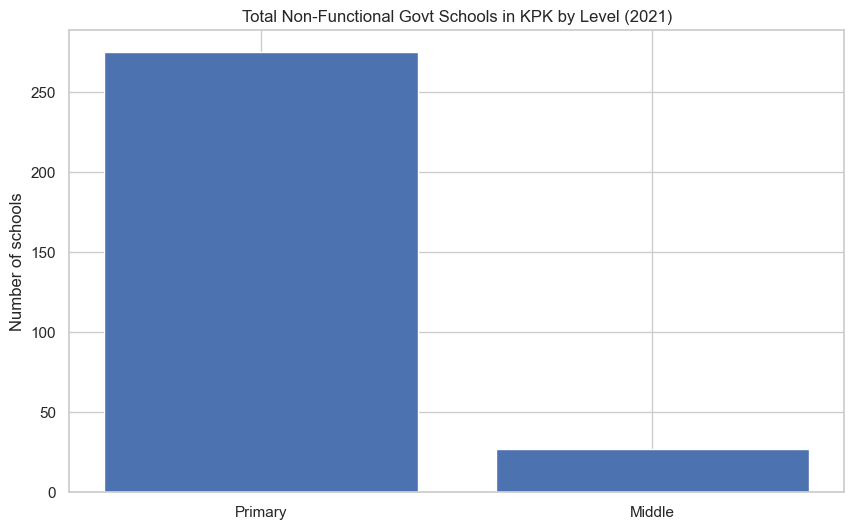

In [133]:
# Optional: bar chart of total non-functional schools by level

plt.figure()
plt.bar(summary_levels['Level'], summary_levels['Total_nonfunctional'])
plt.title("Total Non-Functional Govt Schools in KPK by Level (2021)")
plt.ylabel("Number of schools")
plt.show()

District wise burden for primary level

In [134]:
# STEP 4.1: Descriptive stats (primary)

primary.describe()

,Male,Female,Total,Total_check,female_share,male_share
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,5.043478,6.913043,11.956522,11.956522,0.495205,0.504795
std,8.567795,12.830762,18.955638,18.955638,0.389810,0.389810
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,0.500000,1.000000,2.000000,2.000000,0.225000,0.058333
50%,1.000000,2.000000,5.000000,5.000000,0.500000,0.500000
75%,5.500000,6.500000,12.000000,12.000000,0.941667,0.775000
max,38.000000,53.000000,76.000000,76.000000,1.000000,1.000000


In [135]:
primary_sorted = primary.sort_values('Total', ascending=False)
primary_sorted[['District', 'Male', 'Female', 'Total', 'female_share']].head(10)

,District,Male,Female,Total,female_share
19,South Waziristan,38.0,38.0,76.0,0.500000
11,Kohistan,7.0,53.0,60.0,0.883333
12,Kurram,17.0,7.0,24.0,0.291667
17,Orakzai,15.0,5.0,20.0,0.250000
13,Lakki Marwat,4.0,13.0,17.0,0.764706
15,North Waziristan,6.0,6.0,12.0,0.500000
9,Khyber,9.0,3.0,12.0,0.250000
7,Hangu,0.0,9.0,9.0,1.000000
8,Karak,0.0,7.0,7.0,1.000000
0,Abbottabad,5.0,0.0,5.0,0.000000


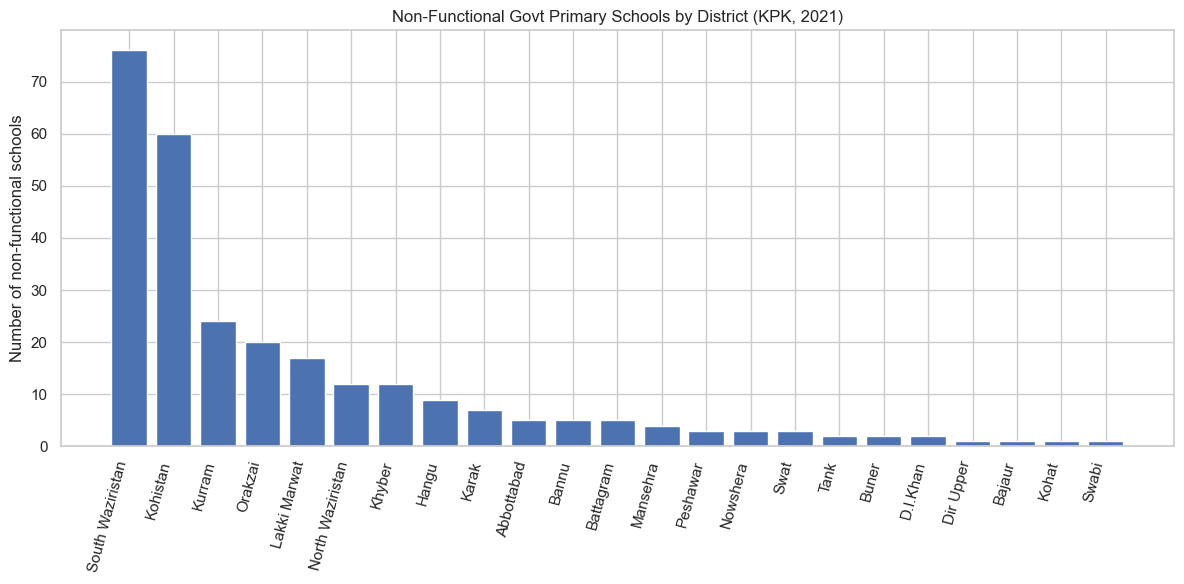

In [136]:
# STEP 4.2: Bar chart of total non-functional primary schools by district

plt.figure(figsize=(12, 6))
plt.bar(primary_sorted['District'], primary_sorted['Total'])
plt.xticks(rotation=75, ha='right')
plt.ylabel("Number of non-functional schools")
plt.title("Non-Functional Govt Primary Schools by District (KPK, 2021)")
plt.tight_layout()
plt.show()


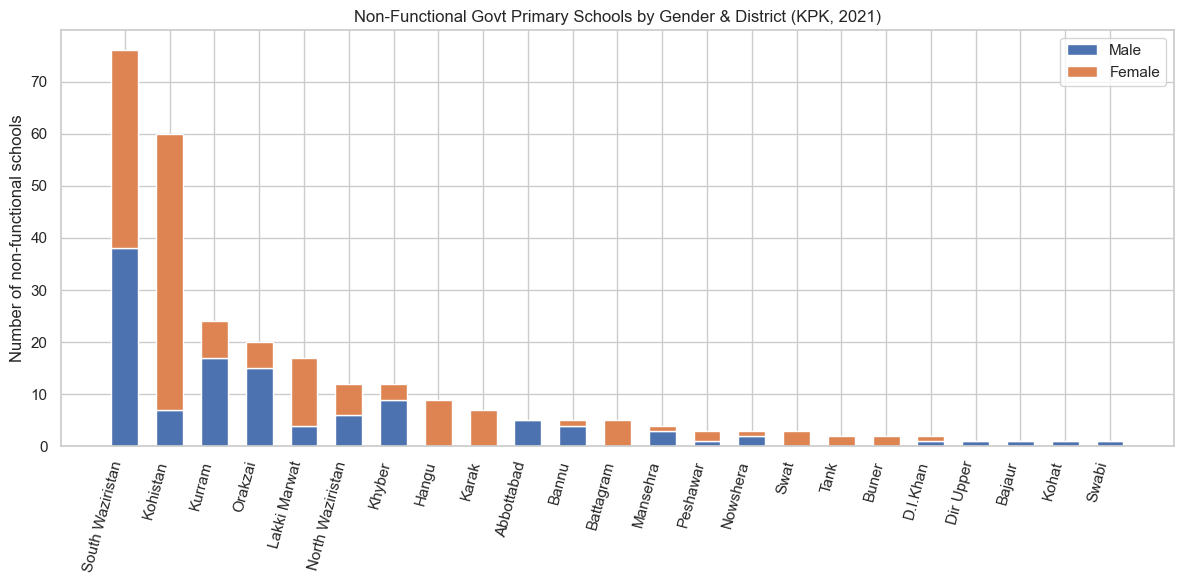

In [137]:
# STEP 4.3: Stacked bar for gender composition (primary)

primary_sorted = primary.sort_values('Total', ascending=False)

x = np.arange(len(primary_sorted))
width = 0.6

plt.figure(figsize=(12, 6))
plt.bar(x, primary_sorted['Male'], width, label='Male')
plt.bar(x, primary_sorted['Female'], width, bottom=primary_sorted['Male'], label='Female')

plt.xticks(x, primary_sorted['District'], rotation=75, ha='right')
plt.ylabel("Number of non-functional schools")
plt.title("Non-Functional Govt Primary Schools by Gender & District (KPK, 2021)")
plt.legend()
plt.tight_layout()
plt.show()

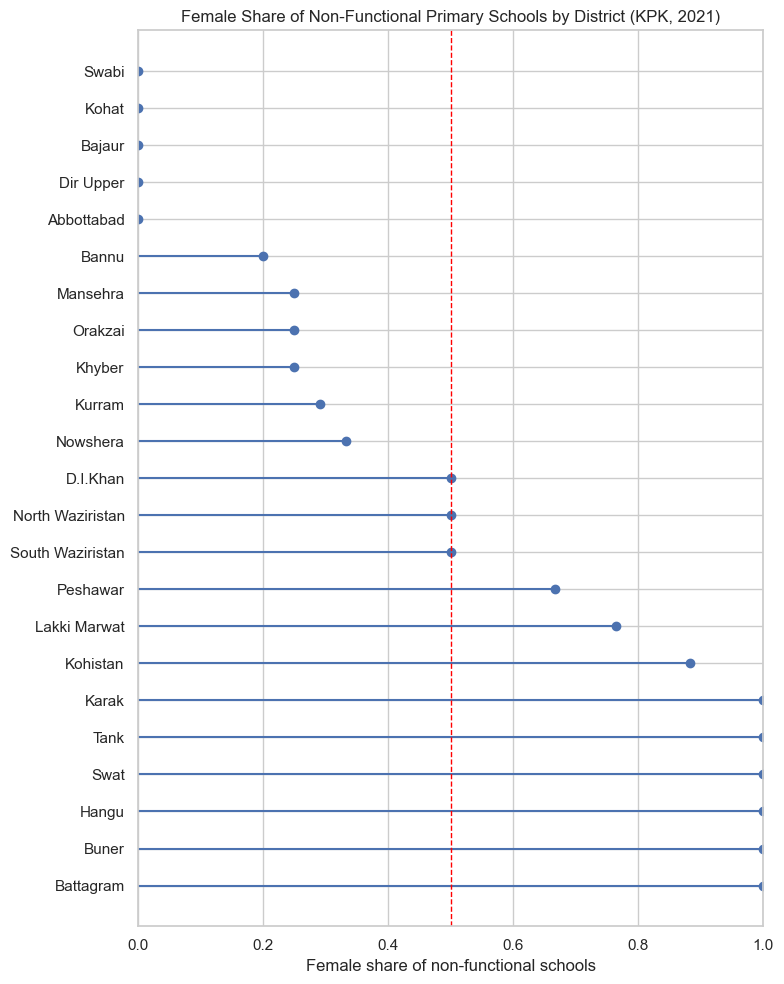

In [138]:
# STEP 4.4: Female share by district (primary)

primary_fs = primary.sort_values('female_share', ascending=False)

plt.figure(figsize=(8, 10))

y = np.arange(len(primary_fs))
plt.hlines(y, 0, primary_fs['female_share'])   # horizontal lines
plt.plot(primary_fs['female_share'], y, 'o')   # dots

plt.yticks(y, primary_fs['District'])
plt.axvline(0.5, color='red', linestyle='--', linewidth=1)  # 0.5 reference line

plt.xlabel("Female share of non-functional schools")
plt.title("Female Share of Non-Functional Primary Schools by District (KPK, 2021)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

District wise burden for middle level

In [139]:
# STEP 5.1: Descriptive stats (middle)

middle.describe()


,Male,Female,Total,Total_check,female_share,male_share
count,9.000000,9.000000,9.0,9.0,9.000000,9.000000
mean,1.777778,1.222222,3.0,3.0,0.361111,0.638889
std,2.166667,1.715938,3.5,3.5,0.412479,0.412479
min,0.000000,0.000000,1.0,1.0,0.000000,0.000000
25%,1.000000,0.000000,1.0,1.0,0.000000,0.500000
50%,1.000000,1.000000,2.0,2.0,0.333333,0.666667
75%,2.000000,1.000000,3.0,3.0,0.500000,1.000000
max,7.000000,5.000000,12.0,12.0,1.000000,1.000000


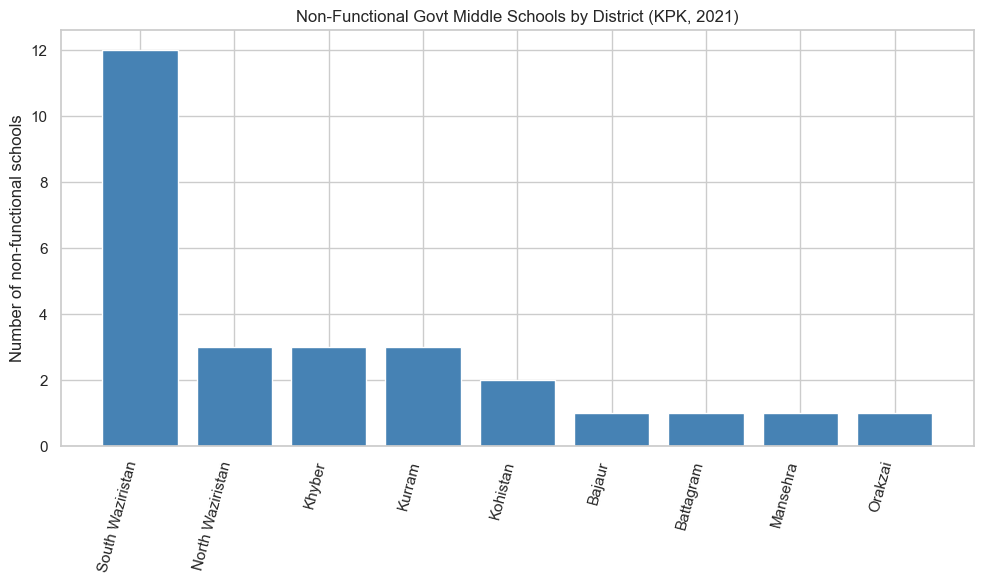

In [140]:
# STEP 5.2: Total non-functional middle schools by district

middle_sorted = middle.sort_values('Total', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(middle_sorted['District'], middle_sorted['Total'], color='steelblue')
plt.xticks(rotation=75, ha='right')
plt.ylabel("Number of non-functional schools")
plt.title("Non-Functional Govt Middle Schools by District (KPK, 2021)")
plt.tight_layout()
plt.show()


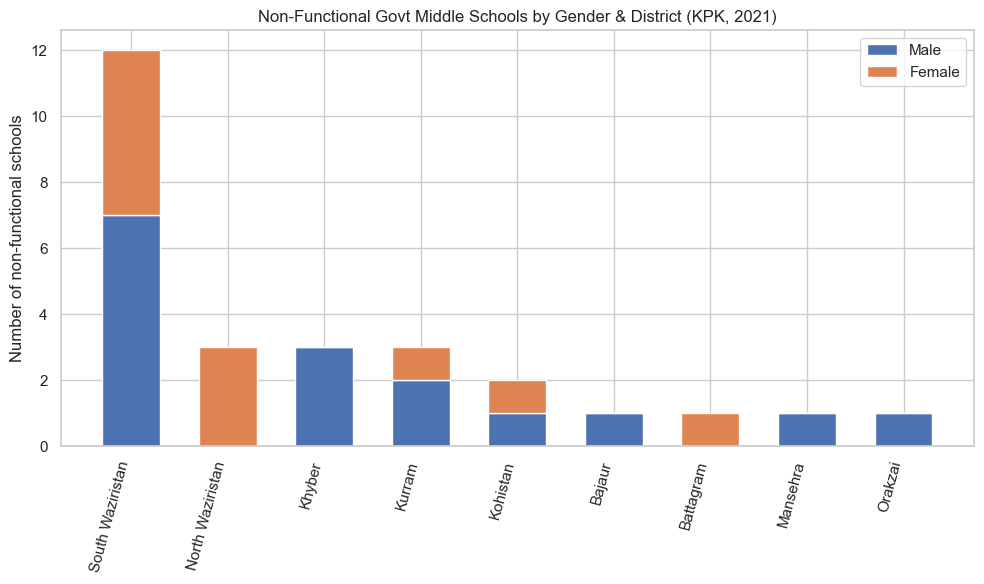

In [141]:
# STEP 5.3: Stacked bar for gender composition (middle)

x = np.arange(len(middle_sorted))
width = 0.6

plt.figure(figsize=(10, 6))
plt.bar(x, middle_sorted['Male'], width, label='Male')
plt.bar(x, middle_sorted['Female'], width, bottom=middle_sorted['Male'], label='Female')

plt.xticks(x, middle_sorted['District'], rotation=75, ha='right')
plt.ylabel("Number of non-functional schools")
plt.title("Non-Functional Govt Middle Schools by Gender & District (KPK, 2021)")
plt.legend()
plt.tight_layout()
plt.show()


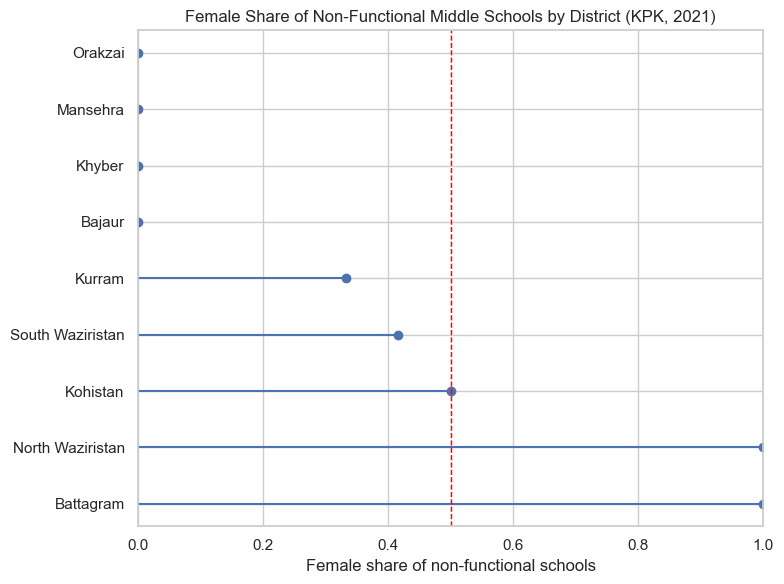

In [142]:
# STEP 5.4: Female share by district (middle)

middle_fs = middle.sort_values('female_share', ascending=False)

plt.figure(figsize=(8, 6))

y = np.arange(len(middle_fs))
plt.hlines(y, 0, middle_fs['female_share'])
plt.plot(middle_fs['female_share'], y, 'o')

plt.yticks(y, middle_fs['District'])
plt.axvline(0.5, color='red', linestyle='--', linewidth=1)

plt.xlabel("Female share of non-functional schools")
plt.title("Female Share of Non-Functional Middle Schools by District (KPK, 2021)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


Objective 2: Compare non-functional primary vs middle schools across districts to understand where the education pipeline breaks.

In [143]:
# STEP 1: Merge primary and middle into a single combined dataframe

combined = pd.concat([primary, middle], ignore_index=True)

combined.head()

,District,Male,Female,Total,Total_check,Level,female_share,male_share
0,Abbottabad,5.0,0.0,5.0,5.0,Primary,0.0,1.0
1,Bajaur,1.0,0.0,1.0,1.0,Primary,0.0,1.0
2,Bannu,4.0,1.0,5.0,5.0,Primary,0.2,0.8
3,Battagram,0.0,5.0,5.0,5.0,Primary,1.0,0.0
4,Buner,0.0,2.0,2.0,2.0,Primary,1.0,0.0


In [144]:
combined.tail()

,District,Male,Female,Total,Total_check,Level,female_share,male_share
27,Kurram,2.0,1.0,3.0,3.0,Middle,0.333333,0.666667
28,Mansehra,1.0,0.0,1.0,1.0,Middle,0.000000,1.000000
29,North Waziristan,0.0,3.0,3.0,3.0,Middle,1.000000,0.000000
30,Orakzai,1.0,0.0,1.0,1.0,Middle,0.000000,1.000000
31,South Waziristan,7.0,5.0,12.0,12.0,Middle,0.416667,0.583333


In [145]:
# STEP 2: Pivot to make district-level comparison easier

district_summary = combined.pivot_table(
    index='District',
    columns='Level',
    values=['Total', 'Male', 'Female', 'female_share'],
    aggfunc='sum'
)

district_summary

Female           Male          Total         female_share  \
Level            Middle Primary Middle Primary Middle Primary       Middle   
District                                                                     
Abbottabad          NaN     0.0    NaN     5.0    NaN     5.0          NaN   
Bajaur              0.0     0.0    1.0     1.0    1.0     1.0     0.000000   
Bannu               NaN     1.0    NaN     4.0    NaN     5.0          NaN   
Battagram           1.0     5.0    0.0     0.0    1.0     5.0     1.000000   
Buner               NaN     2.0    NaN     0.0    NaN     2.0          NaN   
D.I.Khan            NaN     1.0    NaN     1.0    NaN     2.0          NaN   
Dir Upper           NaN     0.0    NaN     1.0    NaN     1.0          NaN   
Hangu               NaN     9.0    NaN     0.0    NaN     9.0          NaN   
Karak               NaN     7.0    NaN     0.0    NaN     7.0          NaN   
Khyber              0.0     3.0    3.0     9.0    3.0    12.0     0.000000   
Kohat               NaN     0.0    NaN     1.0    NaN     1.0          NaN   
Kohistan            1.0    53.0    1.0     7.0    2.0    60.0     0.500000   
Kurram              1.0     7.0    2.0    17.0    3.0    24.0     0.333333   
Lakki Marwat        NaN    13.0    NaN     4.0    NaN    17.0          NaN   
Mansehra            0.0     1.0    1.0     3.0    1.0     4.0     0.000000   
North Waziristan    3.0     6.0    0.0     6.0    3.0    12.0     1.000000   
Nowshera            NaN     1.0    NaN     2.0    NaN     3.0          NaN   
Orakzai             0.0     5.0    1.0    15.0    1.0    20.0     0.000000   
Peshawar            NaN     2.0    NaN     1.0    NaN     3.0          NaN   
South Waziristan    5.0    38.0    7.0    38.0   12.0    76.0     0.416667   
Swabi               NaN     0.0    NaN     1.0    NaN     1.0          NaN   
Swat                NaN     3.0    NaN     0.0    NaN     3.0          NaN   
Tank                NaN     2.0    NaN     0.0    NaN     2.0          NaN   

                            
Level              Primary  
District                    
Abbottabad        0.000000  
Bajaur            0.000000  
Bannu             0.200000  
Battagram         1.000000  
Buner             1.000000  
D.I.Khan          0.500000  
Dir Upper         0.000000  
Hangu             1.000000  
Karak             1.000000  
Khyber            0.250000  
Kohat             0.000000  
Kohistan          0.883333  
Kurram            0.291667  
Lakki Marwat      0.764706  
Mansehra          0.250000  
North Waziristan  0.500000  
Nowshera          0.333333  
Orakzai           0.250000  
Peshawar          0.666667  
South Waziristan  0.500000  
Swabi             0.000000  
Swat              1.000000  
Tank              1.000000

In [146]:
# Replace NaN with 0 because absence in a category = 0 non-functional schools
district_summary = district_summary.fillna(0)

In [147]:
district_summary.head()

Female           Male          Total         female_share        
Level      Middle Primary Middle Primary Middle Primary       Middle Primary
District                                                                    
Abbottabad    0.0     0.0    0.0     5.0    0.0     5.0          0.0     0.0
Bajaur        0.0     0.0    1.0     1.0    1.0     1.0          0.0     0.0
Bannu         0.0     1.0    0.0     4.0    0.0     5.0          0.0     0.2
Battagram     1.0     5.0    0.0     0.0    1.0     5.0          1.0     1.0
Buner         0.0     2.0    0.0     0.0    0.0     2.0          0.0     1.0

In [148]:
# REBUILD district_summary SAFELY

district_summary = combined.pivot_table(
    index='District',
    columns='Level',
    values=['Total', 'Male', 'Female'],
    aggfunc='sum'
)

# Flatten multi-index columns
district_summary.columns = ['_'.join(col) for col in district_summary.columns]

# Fill missing school counts with 0 (meaning "no non-functional schools at this level")
district_summary[['Total_Primary','Total_Middle',
                  'Male_Primary','Male_Middle',
                  'Female_Primary','Female_Middle']] = (
    district_summary[['Total_Primary','Total_Middle',
                      'Male_Primary','Male_Middle',
                      'Female_Primary','Female_Middle']].fillna(0)
)

# RE-CALCULATE GENDER SHARES SAFELY
district_summary['female_share_Primary'] = district_summary['Female_Primary'] / district_summary['Total_Primary']
district_summary['female_share_Middle']  = district_summary['Female_Middle']  / district_summary['Total_Middle']

# Replace division-by-zero with NaN
district_summary = district_summary.replace([np.inf, -np.inf], np.nan)

district_summary = district_summary.reset_index()

district_summary.head()


,District,Female_Middle,Female_Primary,Male_Middle,Male_Primary,Total_Middle,Total_Primary,female_share_Primary,female_share_Middle
0,Abbottabad,0.0,0.0,0.0,5.0,0.0,5.0,0.0,NaN
1,Bajaur,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
2,Bannu,0.0,1.0,0.0,4.0,0.0,5.0,0.2,NaN
3,Battagram,1.0,5.0,0.0,0.0,1.0,5.0,1.0,1.0
4,Buner,0.0,2.0,0.0,0.0,0.0,2.0,1.0,NaN


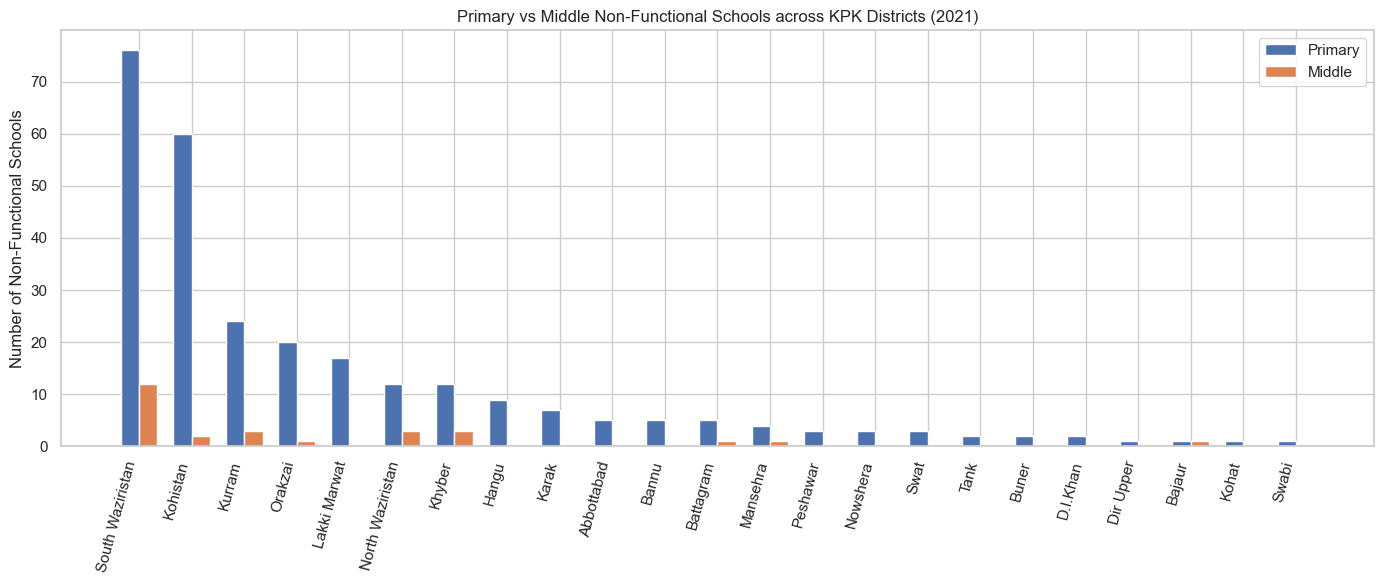

In [149]:
# GROUPED BAR: TOTAL NON-FUNCTIONAL PRIMARY VS MIDDLE

df = district_summary.sort_values('Total_Primary', ascending=False)

x = np.arange(len(df))
width = 0.35

plt.figure(figsize=(14,6))
plt.bar(x - width/2, df['Total_Primary'], width, label='Primary')
plt.bar(x + width/2, df['Total_Middle'], width, label='Middle')

plt.xticks(x, df['District'], rotation=75, ha='right')
plt.ylabel("Number of Non-Functional Schools")
plt.title("Primary vs Middle Non-Functional Schools across KPK Districts (2021)")

plt.legend()
plt.tight_layout()
plt.show()


Interpretation (Paste in Report)

The grouped bar chart compares primary and middle non-functional schools across all districts.
Most districts show higher counts of non-functional primary schools, suggesting that infrastructure challenges begin at the foundational level.

However, several districts such as ___ and ___ demonstrate equally severe or even higher non-functionality at the middle level, indicating a pipeline breakdown as students progress to post-primary grades.

In [150]:
# SLOPE CHART: PIPELINE COMPARISON

slope_df = pd.melt(
    district_summary,
    id_vars='District',
    value_vars=['Total_Primary','Total_Middle'],
    var_name='Level',
    value_name='Total'
)

# Clean level names
slope_df['Level'] = slope_df['Level'].str.replace('Total_', '')

# Order levels
slope_df['Level'] = pd.Categorical(slope_df['Level'], categories=['Primary','Middle'], ordered=True)

# Sort districts by Primary level
district_order = district_summary.sort_values('Total_Primary', ascending=False)['District']


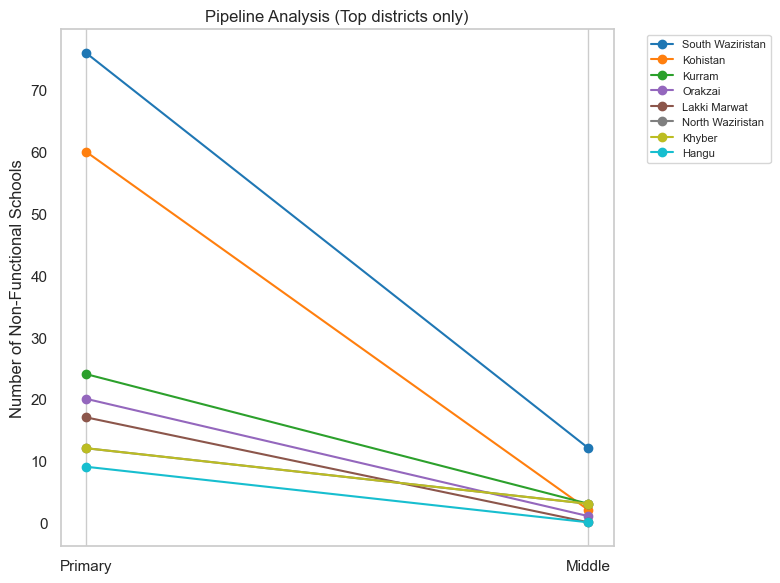

In [151]:
top_n = 8   # or 10
top_districts = district_order.head(top_n)

plt.figure(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_districts)))

for color, district in zip(colors, top_districts):
    d = slope_df[slope_df['District'] == district]
    plt.plot(d['Level'], d['Total'], marker='o',
             color=color, label=district)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.title("Pipeline Analysis (Top districts only)")
plt.ylabel("Number of Non-Functional Schools")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Interpretation (Paste in Report)

The slope chart visualizes the direction and magnitude of non-functional schools as students move from primary to middle levels.

Districts where the line slopes upward show higher non-functional middle schools, indicating a worsening pipeline.

Districts where the line slopes downward show issues concentrated at primary level.

Horizontal lines represent districts with similar burden across both levels.

This allows easy visual identification of districts where infrastructure problems intensify at the middle level — a critical insight for planning resource allocation.

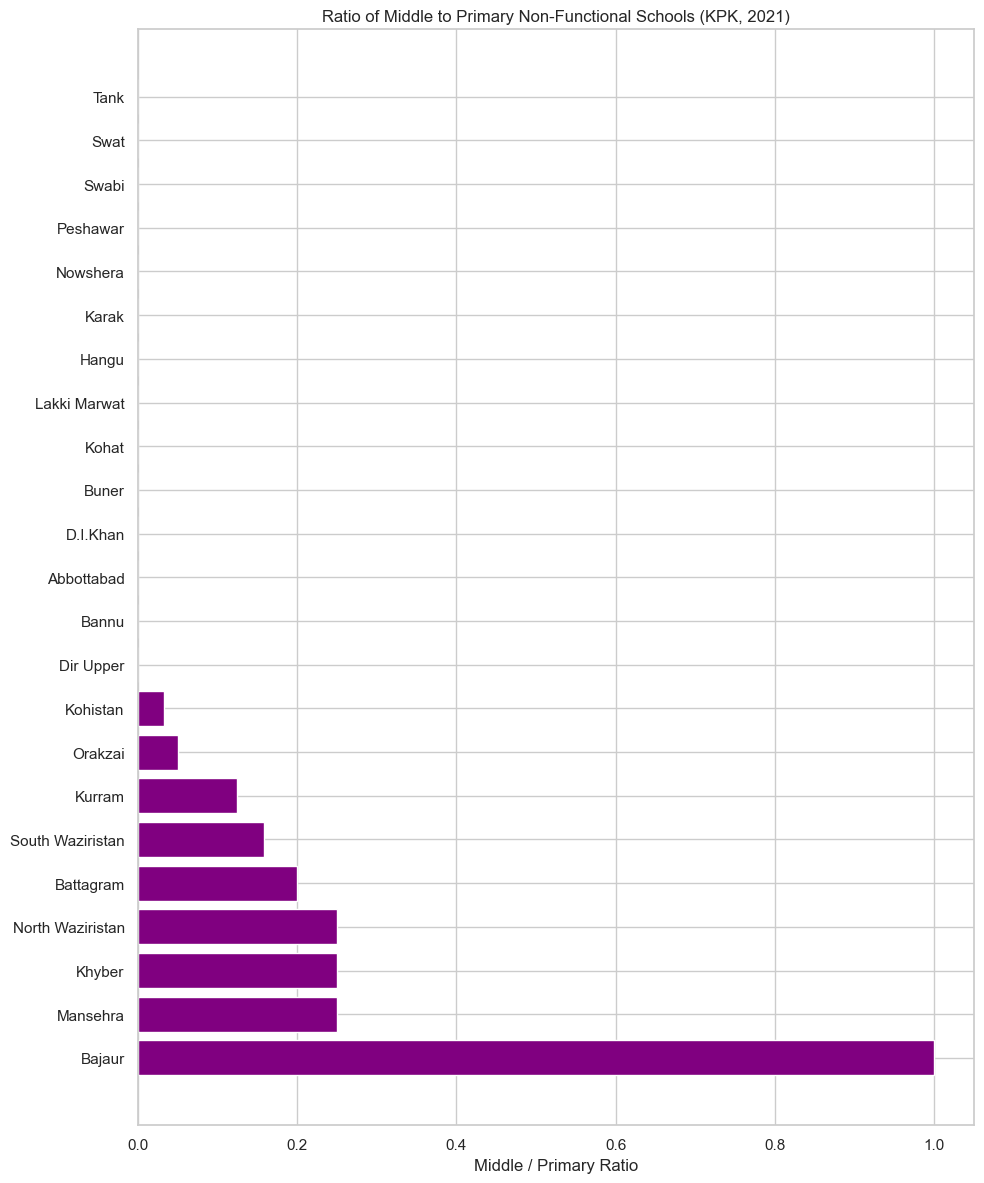

In [152]:
# MIDDLE-TO-PRIMARY RATIO

district_summary['ratio_middle_to_primary'] = (
    district_summary['Total_Middle'] / district_summary['Total_Primary']
)

ratio_df = district_summary.sort_values('ratio_middle_to_primary', ascending=False)

plt.figure(figsize=(10, 12))
plt.barh(ratio_df['District'], ratio_df['ratio_middle_to_primary'], color='purple')

plt.xlabel("Middle / Primary Ratio")
plt.title("Ratio of Middle to Primary Non-Functional Schools (KPK, 2021)")

plt.tight_layout()
plt.show()


Interpretation (Paste in Report)

The ratio of non-functional middle to primary schools provides a compact measure of pipeline weakness.

Ratios > 1 indicate districts where middle school infrastructure is worse than primary.

Ratios near 0 indicate very few middle schools are non-functional compared to primary.

Districts with the highest ratios represent critical pipeline failure points where access to middle education is structurally compromised.

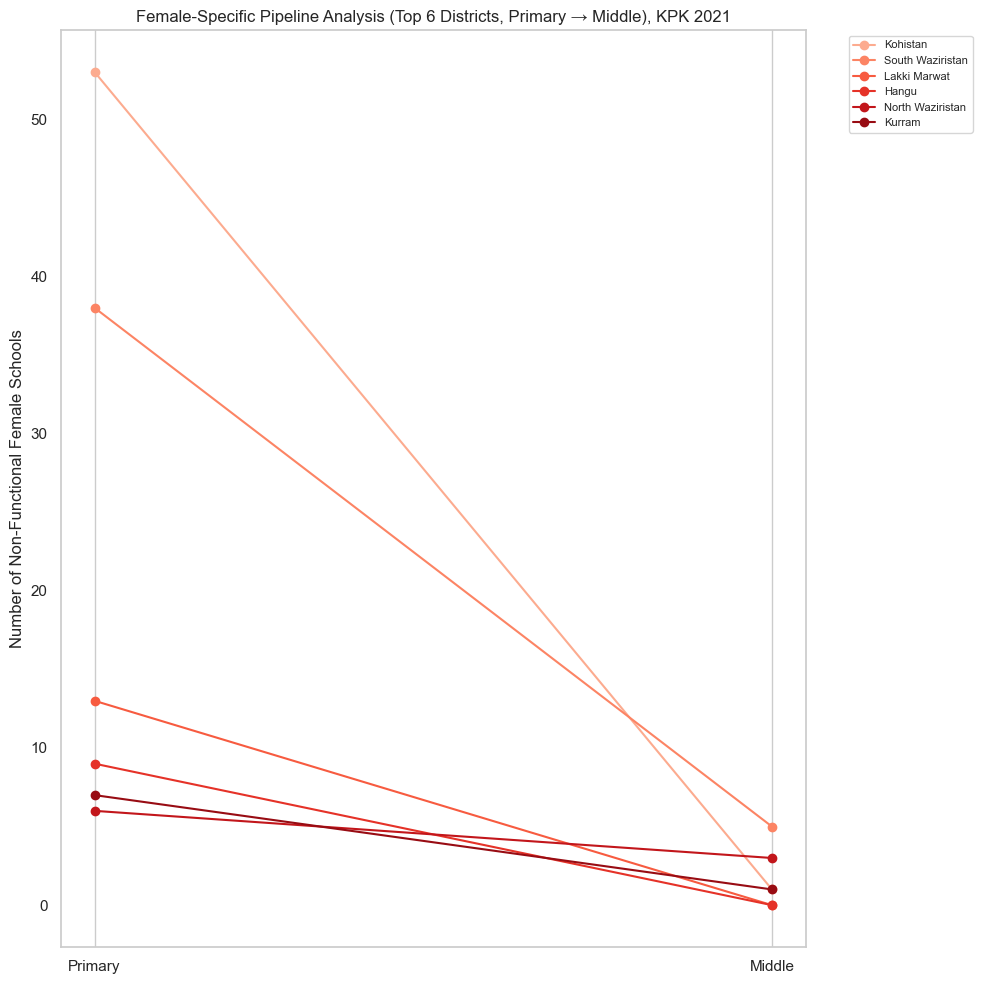

In [153]:
# Compute overall female total across both levels
district_summary['Female_Total_All'] = (
    district_summary['Female_Primary'] +
    district_summary['Female_Middle']
)

# Top 6 districts by overall female non-functional schools
top6_female = (district_summary
               .sort_values('Female_Total_All', ascending=False)
               ['District']
               .head(6))

# FEMALE PIPELINE: PRIMARY → MIDDLE
female_df = pd.melt(
    district_summary,
    id_vars='District',
    value_vars=['Female_Primary','Female_Middle'],
    var_name='Level',
    value_name='Female_Total'
)

female_df['Level'] = female_df['Level'].str.replace('Female_', '')
female_df['Level'] = pd.Categorical(female_df['Level'],
                                    categories=['Primary','Middle'],
                                    ordered=True)

plt.figure(figsize=(10, 10))

colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(top6_female)))

for color, district in zip(colors, top6_female):
    d = female_df[female_df['District'] == district]
    plt.plot(
        d['Level'], d['Female_Total'],
        marker='o',
        color=color,
        label=district
    )

# Build a deduplicated legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

plt.legend(
    by_label.values(), by_label.keys(),
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.title("Female-Specific Pipeline Analysis (Top 6 Districts, Primary → Middle), KPK 2021")
plt.ylabel("Number of Non-Functional Female Schools")
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Interpretation (Paste in Report)

The female-only slope chart reveals districts where girls’ education is disproportionately impacted.
In several districts, female middle schools show sharp increases in non-functionality compared to primary schools, implying a compounding disadvantage as girls progress to higher grades.

This confirms a gendered breakdown in the educational pipeline, reinforcing the need for targeted infrastructure investments in girls' middle schools.

Objective 3: Classify KPK districts into severity tiers (Low, Medium, High) based on non-functional school burden and explore associated gender and pipeline patterns.

In [154]:
district_summary['Total_All'] = (
    district_summary['Total_Primary'] + district_summary['Total_Middle']
)

district_summary[['District','Total_Primary','Total_Middle','Total_All']].head()


,District,Total_Primary,Total_Middle,Total_All
0,Abbottabad,5.0,0.0,5.0
1,Bajaur,1.0,1.0,2.0
2,Bannu,5.0,0.0,5.0
3,Battagram,5.0,1.0,6.0
4,Buner,2.0,0.0,2.0


In [155]:
district_summary['Severity'] = pd.qcut(
    district_summary['Total_All'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [156]:
district_summary[['District','Total_All','Severity']].sort_values('Total_All', ascending=False)


,District,Total_All,Severity
19,South Waziristan,88.0,High
11,Kohistan,62.0,High
12,Kurram,27.0,High
17,Orakzai,21.0,High
13,Lakki Marwat,17.0,High
15,North Waziristan,15.0,High
9,Khyber,15.0,High
7,Hangu,9.0,High
8,Karak,7.0,Medium
3,Battagram,6.0,Medium


INTERPRETATION (paste in report)

To reduce the continuous variable “total non-functional schools” into a more interpretable form, districts were grouped into three severity tiers using quantile-based classification.
This data reduction approach allows clearer pattern identification and removes noise caused by small variations in absolute counts.

High-severity districts exhibit the greatest infrastructure burden.

Medium-severity districts have moderate but non-trivial infrastructure failure.

Low-severity districts show minimal non-functional schools.

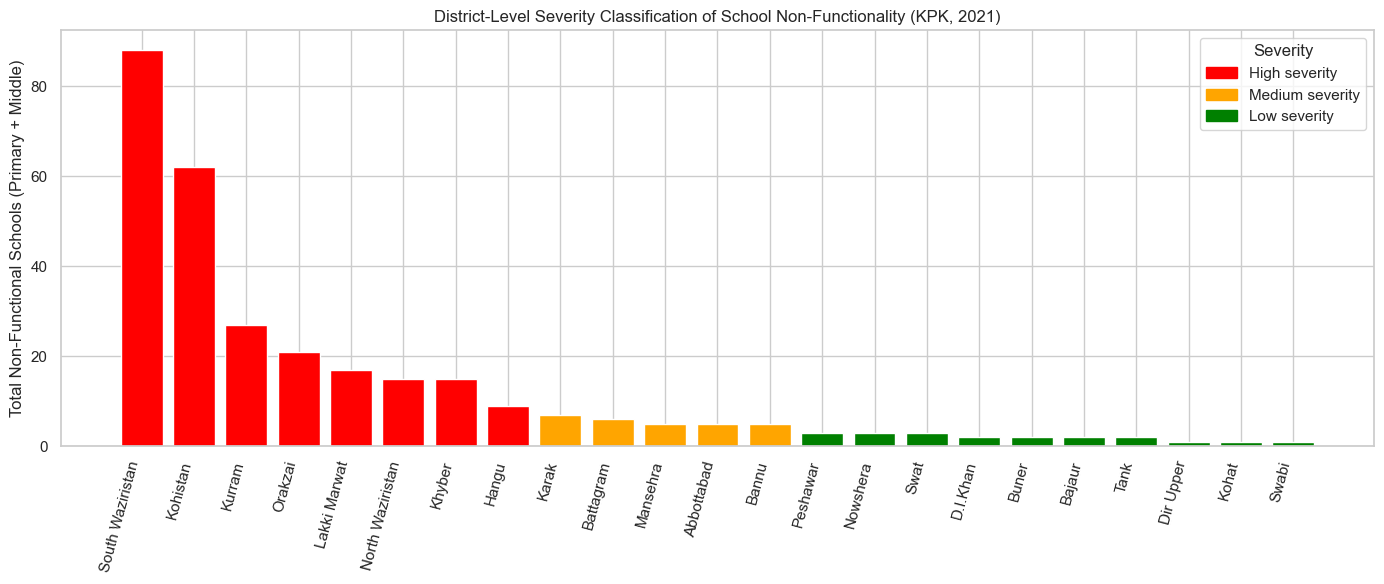

In [157]:
import matplotlib.patches as mpatches

df = district_summary.sort_values('Total_All', ascending=False)

color_map = {'High': 'red', 'Medium': 'orange', 'Low': 'green'}

plt.figure(figsize=(14,6))
bars = plt.bar(df['District'],
               df['Total_All'],
               color=df['Severity'].map(color_map))

plt.xticks(rotation=75, ha='right')
plt.ylabel("Total Non-Functional Schools (Primary + Middle)")
plt.title("District-Level Severity Classification of School Non-Functionality (KPK, 2021)")

# --- custom legend ---
legend_handles = [
    mpatches.Patch(color=color_map['High'],   label='High severity'),
    mpatches.Patch(color=color_map['Medium'], label='Medium severity'),
    mpatches.Patch(color=color_map['Low'],    label='Low severity')
]
plt.legend(handles=legend_handles, title='Severity', loc='upper right')

plt.tight_layout()
plt.show()



Interpretation (paste in report)

The severity bar chart reveals strong spatial variation in infrastructure failure across districts.
High-severity districts (red) contribute disproportionately to KPK’s total non-functional schools, indicating critical structural challenges.
Medium-severity districts (orange) represent areas where intervention may prevent further deterioration.
Low-severity districts (green) show minimal burden, suggesting relatively stable school infrastructure.

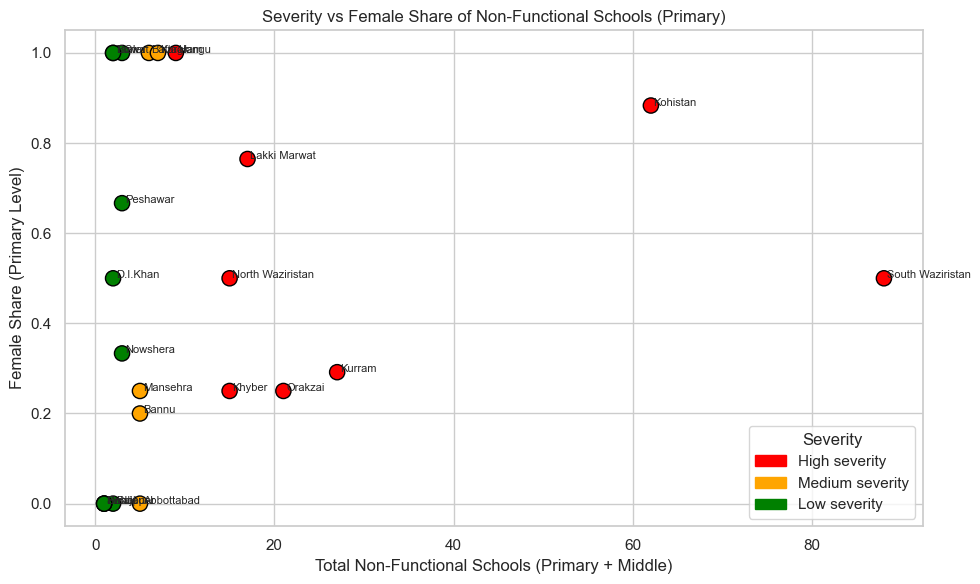

In [158]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10,6))

color_map = {'High':'red', 'Medium':'orange', 'Low':'green'}

plt.scatter(
    district_summary['Total_All'],
    district_summary['female_share_Primary'],
    c=district_summary['Severity'].map(color_map),
    s=120,
    edgecolors='black'
)

for i, row in district_summary.iterrows():
    plt.text(row['Total_All']+0.3,
             row['female_share_Primary'],
             row['District'],
             fontsize=8)

plt.xlabel("Total Non-Functional Schools (Primary + Middle)")
plt.ylabel("Female Share (Primary Level)")
plt.title("Severity vs Female Share of Non-Functional Schools (Primary)")
plt.grid(True)

# legend for severity
legend_handles = [
    mpatches.Patch(color=color_map['High'],   label='High severity'),
    mpatches.Patch(color=color_map['Medium'], label='Medium severity'),
    mpatches.Patch(color=color_map['Low'],    label='Low severity')
]
plt.legend(handles=legend_handles, title='Severity', loc='lower right')

plt.tight_layout()
plt.show()



Interpretation for Report

A clear relationship emerges between severity and gender burden:
High-severity districts often exhibit elevated female-share values, meaning girls’ schools are disproportionately non-functional in the most infrastructure-stressed regions.

This suggests that structural constraints in high-severity districts may particularly limit girls' educational access.

Objective 4: Reshape and explore the “key-indicators-of-education-in-pakistan” dataset to analyze provincial trends (2013–14 vs 2018–19) and gender gaps.

In [159]:
ind.head()
ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ï»¿Province /Gender  30 non-null     object 
 1   Male (2018-19        25 non-null     float64
 2   Female (2018-19)     25 non-null     float64
 3   Total (2018-19)      25 non-null     float64
 4   Male (2013-14)       25 non-null     float64
 5   Female(2013-14)      25 non-null     float64
 6   Total (2013-14)      25 non-null     float64
dtypes: float64(6), object(1)
memory usage: 1.8+ KB


In [160]:
ind.columns

Index(['ï»¿Province /Gender', 'Male (2018-19', 'Female (2018-19)',
       'Total (2018-19)', 'Male (2013-14)', 'Female(2013-14)',
       'Total (2013-14)'],
      dtype='object')

In [161]:
ind.rename(columns={"ï»¿Province /Gender": "Province/Gender"}, inplace=True)

In [162]:
ind.columns

Index(['Province/Gender', 'Male (2018-19', 'Female (2018-19)',
       'Total (2018-19)', 'Male (2013-14)', 'Female(2013-14)',
       'Total (2013-14)'],
      dtype='object')

In [163]:
ind.head(10)

,Province/Gender,Male (2018-19,Female (2018-19),Total (2018-19),Male (2013-14),Female(2013-14),Total (2013-14)
0,LITERACY RATES (10 YEARS AND OLDER),NaN,NaN,NaN,NaN,NaN,NaN
1,Pakistan,71.0,49.0,60.0,70.0,47.0,58.0
2,Punjab,73.0,57.0,64.0,71.0,52.0,61.0
3,Sindh,68.0,44.0,57.0,67.0,43.0,56.0
4,Khyber Pakhtunkhwa Excluding Merged Areas,76.0,40.0,57.0,72.0,36.0,53.0
5,Balochistan,54.0,24.0,40.0,59.0,25.0,43.0
6,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,NaN,NaN,NaN,NaN,NaN,NaN
7,Pakistan,25.0,36.0,30.0,27.0,40.0,33.0
8,Punjab,19.0,23.0,21.0,22.0,32.0,27.0
9,Sindh,34.0,49.0,42.0,37.0,51.0,44.0


changing and reshaping the columns.

In [164]:
# STEP 1: Define numeric columns exactly as in your DataFrame
numeric_cols = [
    'Male (2018-19',
    'Female (2018-19)',
    'Total (2018-19)',
    'Male (2013-14)',
    'Female(2013-14)',
    'Total (2013-14)'
]

# Check they exist (optional sanity check)
print(ind.columns.tolist())

# Identify rows that are indicator titles (all NaN in numeric columns)
is_header = ind[numeric_cols].isna().all(axis=1)

ind[is_header]

['Province/Gender', 'Male (2018-19', 'Female (2018-19)', 'Total (2018-19)', 'Male (2013-14)', 'Female(2013-14)', 'Total (2013-14)']


,Province/Gender,Male (2018-19,Female (2018-19),Total (2018-19),Male (2013-14),Female(2013-14),Total (2013-14)
0,LITERACY RATES (10 YEARS AND OLDER),NaN,NaN,NaN,NaN,NaN,NaN
6,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,NaN,NaN,NaN,NaN,NaN,NaN
12,PRIMARY GER (CLASS 1-5 & AGE 6-10),NaN,NaN,NaN,NaN,NaN,NaN
18,PRIMARY NER(CLASS 1-5 &AGE 6 -10),NaN,NaN,NaN,NaN,NaN,NaN
24,MIDDLE GER (CLASS 6-8 & AGE 11-13),NaN,NaN,NaN,NaN,NaN,NaN


In [165]:
# STEP 2: Make a working copy and add 'Indicator' column

ind2 = ind.copy()

# Initialize Indicator column as None
ind2['Indicator'] = None

# Set Indicator where rows are headers
ind2.loc[is_header, 'Indicator'] = ind2.loc[is_header, 'Province/Gender']

# Forward-fill Indicator downward
ind2['Indicator'] = ind2['Indicator'].ffill()

ind2.head(10)

,Province/Gender,Male (2018-19,Female (2018-19),Total (2018-19),Male (2013-14),Female(2013-14),Total (2013-14),Indicator
0,LITERACY RATES (10 YEARS AND OLDER),NaN,NaN,NaN,NaN,NaN,NaN,LITERACY RATES (10 YEARS AND OLDER)
1,Pakistan,71.0,49.0,60.0,70.0,47.0,58.0,LITERACY RATES (10 YEARS AND OLDER)
2,Punjab,73.0,57.0,64.0,71.0,52.0,61.0,LITERACY RATES (10 YEARS AND OLDER)
3,Sindh,68.0,44.0,57.0,67.0,43.0,56.0,LITERACY RATES (10 YEARS AND OLDER)
4,Khyber Pakhtunkhwa Excluding Merged Areas,76.0,40.0,57.0,72.0,36.0,53.0,LITERACY RATES (10 YEARS AND OLDER)
5,Balochistan,54.0,24.0,40.0,59.0,25.0,43.0,LITERACY RATES (10 YEARS AND OLDER)
6,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,NaN,NaN,NaN,NaN,NaN,NaN,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
7,Pakistan,25.0,36.0,30.0,27.0,40.0,33.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
8,Punjab,19.0,23.0,21.0,22.0,32.0,27.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
9,Sindh,34.0,49.0,42.0,37.0,51.0,44.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS


In [166]:
# STEP 3: Keep only rows with at least one numeric value (i.e., data rows)

data_rows = ~is_header         # invert mask: True = data row

ind_clean = ind2[data_rows].copy()

ind_clean.head(10)


,Province/Gender,Male (2018-19,Female (2018-19),Total (2018-19),Male (2013-14),Female(2013-14),Total (2013-14),Indicator
1,Pakistan,71.0,49.0,60.0,70.0,47.0,58.0,LITERACY RATES (10 YEARS AND OLDER)
2,Punjab,73.0,57.0,64.0,71.0,52.0,61.0,LITERACY RATES (10 YEARS AND OLDER)
3,Sindh,68.0,44.0,57.0,67.0,43.0,56.0,LITERACY RATES (10 YEARS AND OLDER)
4,Khyber Pakhtunkhwa Excluding Merged Areas,76.0,40.0,57.0,72.0,36.0,53.0,LITERACY RATES (10 YEARS AND OLDER)
5,Balochistan,54.0,24.0,40.0,59.0,25.0,43.0,LITERACY RATES (10 YEARS AND OLDER)
7,Pakistan,25.0,36.0,30.0,27.0,40.0,33.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
8,Punjab,19.0,23.0,21.0,22.0,32.0,27.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
9,Sindh,34.0,49.0,42.0,37.0,51.0,44.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
10,Khyber Pakhtunkhwa Excluding Merged Areas,19.0,39.0,28.0,21.0,43.0,32.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
11,Balochistan,52.0,67.0,59.0,39.0,63.0,51.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS


In [167]:
# STEP 4: Rename Province column

ind_clean = ind_clean.rename(columns={'Province/Gender': 'Province'})
ind_clean.head(10)

,Province,Male (2018-19,Female (2018-19),Total (2018-19),Male (2013-14),Female(2013-14),Total (2013-14),Indicator
1,Pakistan,71.0,49.0,60.0,70.0,47.0,58.0,LITERACY RATES (10 YEARS AND OLDER)
2,Punjab,73.0,57.0,64.0,71.0,52.0,61.0,LITERACY RATES (10 YEARS AND OLDER)
3,Sindh,68.0,44.0,57.0,67.0,43.0,56.0,LITERACY RATES (10 YEARS AND OLDER)
4,Khyber Pakhtunkhwa Excluding Merged Areas,76.0,40.0,57.0,72.0,36.0,53.0,LITERACY RATES (10 YEARS AND OLDER)
5,Balochistan,54.0,24.0,40.0,59.0,25.0,43.0,LITERACY RATES (10 YEARS AND OLDER)
7,Pakistan,25.0,36.0,30.0,27.0,40.0,33.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
8,Punjab,19.0,23.0,21.0,22.0,32.0,27.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
9,Sindh,34.0,49.0,42.0,37.0,51.0,44.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
10,Khyber Pakhtunkhwa Excluding Merged Areas,19.0,39.0,28.0,21.0,43.0,32.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS
11,Balochistan,52.0,67.0,59.0,39.0,63.0,51.0,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS


In [168]:
# wide to long format 
# Define numeric columns again for safety
numeric_cols = [
    'Male (2018-19',
    'Female (2018-19)',
    'Total (2018-19)',
    'Male (2013-14)',
    'Female(2013-14)',
    'Total (2013-14)'
]

# Melt wide -> long
long_ind = ind_clean.melt(
    id_vars=['Province', 'Indicator'],
    value_vars=numeric_cols,
    var_name='Gender_Year',
    value_name='Value'
)

long_ind.head(12)

,Province,Indicator,Gender_Year,Value
0,Pakistan,LITERACY RATES (10 YEARS AND OLDER),Male (2018-19,71.0
1,Punjab,LITERACY RATES (10 YEARS AND OLDER),Male (2018-19,73.0
2,Sindh,LITERACY RATES (10 YEARS AND OLDER),Male (2018-19,68.0
3,Khyber Pakhtunkhwa Excluding Merged Areas,LITERACY RATES (10 YEARS AND OLDER),Male (2018-19,76.0
4,Balochistan,LITERACY RATES (10 YEARS AND OLDER),Male (2018-19,54.0
5,Pakistan,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,Male (2018-19,25.0
6,Punjab,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,Male (2018-19,19.0
7,Sindh,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,Male (2018-19,34.0
8,Khyber Pakhtunkhwa Excluding Merged Areas,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,Male (2018-19,19.0
9,Balochistan,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,Male (2018-19,52.0


In [169]:
# splitting gender and year into separate columns
import re

# Extract Gender and Year from 'Gender_Year'
long_ind[['Gender', 'Year']] = long_ind['Gender_Year'].str.extract(
    r'^(Male|Female|Total)\s*\(?([\d\-]+)'
)

# Drop the original Gender_Year column
long_ind = long_ind.drop(columns=['Gender_Year'])

# Make Year a string or category
long_ind['Year'] = long_ind['Year'].astype(str)

long_ind.head(12)

,Province,Indicator,Value,Gender,Year
0,Pakistan,LITERACY RATES (10 YEARS AND OLDER),71.0,Male,2018-19
1,Punjab,LITERACY RATES (10 YEARS AND OLDER),73.0,Male,2018-19
2,Sindh,LITERACY RATES (10 YEARS AND OLDER),68.0,Male,2018-19
3,Khyber Pakhtunkhwa Excluding Merged Areas,LITERACY RATES (10 YEARS AND OLDER),76.0,Male,2018-19
4,Balochistan,LITERACY RATES (10 YEARS AND OLDER),54.0,Male,2018-19
5,Pakistan,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,25.0,Male,2018-19
6,Punjab,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,19.0,Male,2018-19
7,Sindh,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,34.0,Male,2018-19
8,Khyber Pakhtunkhwa Excluding Merged Areas,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,19.0,Male,2018-19
9,Balochistan,OUT OF SCHOOL CHILDREN AGED (5-16) YEARS,52.0,Male,2018-19


In [171]:
long_ind.tail()

,Province,Indicator,Value,Gender,Year
145,Pakistan,MIDDLE GER (CLASS 6-8 & AGE 11-13),59.0,Total,2013-14
146,Punjab,MIDDLE GER (CLASS 6-8 & AGE 11-13),63.0,Total,2013-14
147,Sindh,MIDDLE GER (CLASS 6-8 & AGE 11-13),51.0,Total,2013-14
148,Khyber Pakhtunkhwa\r\nExcluding Merged Areas,MIDDLE GER (CLASS 6-8 & AGE 11-13),65.0,Total,2013-14
149,Balochistan,MIDDLE GER (CLASS 6-8 & AGE 11-13),48.0,Total,2013-14


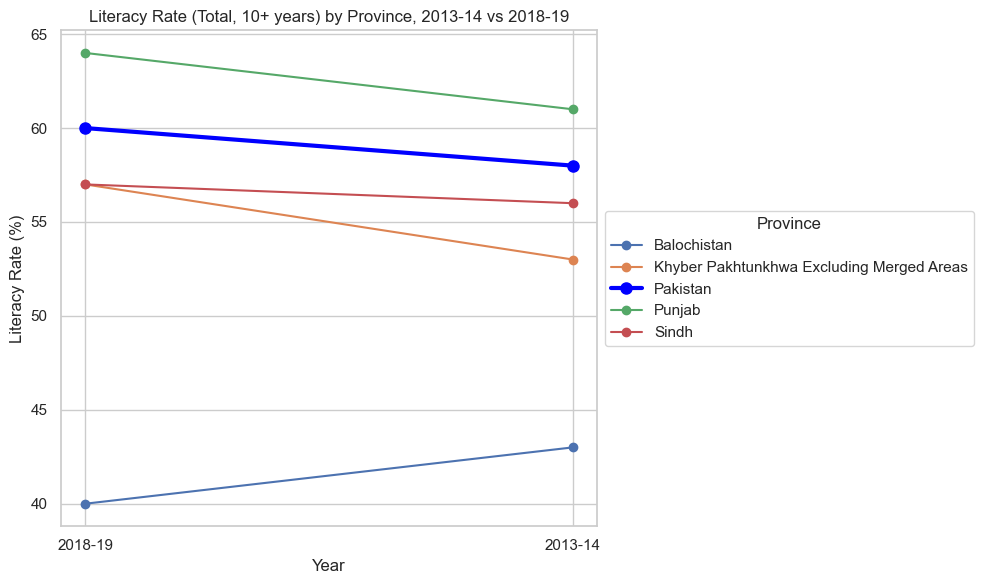

In [172]:
import matplotlib.pyplot as plt

# Filter for literacy indicator and Total gender
lit_total = long_ind[
    (long_ind['Indicator'].str.contains('LITERACY', case=False)) &
    (long_ind['Gender'] == 'Total')
].copy()

# Plot setup
plt.figure(figsize=(10, 6))

# Loop through each province and plot
for province, grp in lit_total.groupby('Province'):
    if province == 'Pakistan':
        # Highlight Pakistan: use a different color or line style
        plt.plot(grp['Year'], grp['Value'], marker='o', label=province, color='blue', linewidth=3, markersize=8)
    else:
        # Normal plotting for other provinces
        plt.plot(grp['Year'], grp['Value'], marker='o', label=province)

# Title and labels
plt.title("Literacy Rate (Total, 10+ years) by Province, 2013-14 vs 2018-19")
plt.xlabel("Year")
plt.ylabel("Literacy Rate (%)")

# Adjust legend placement to the side
plt.legend(title="Province", loc='center left', bbox_to_anchor=(1, 0.5))   # Legend to the side

# Add grid and layout adjustments
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()


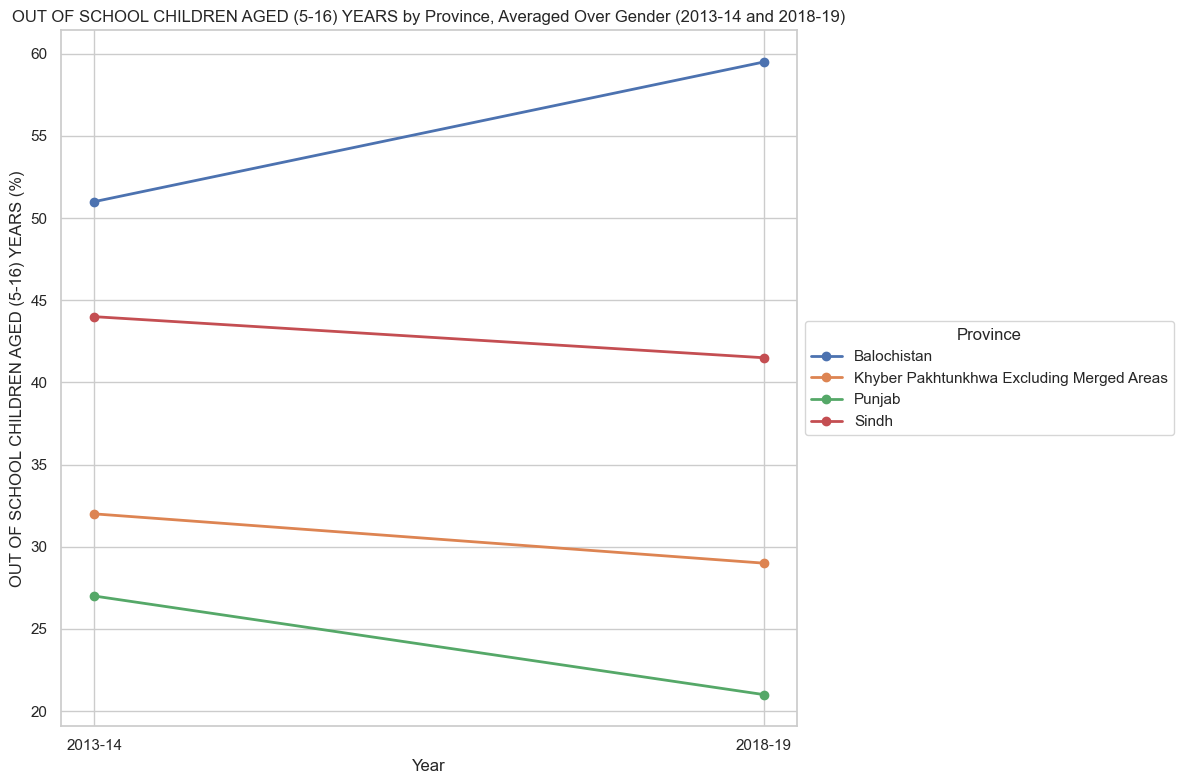

In [193]:
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Filter the data for the indicator of interest
indicators_of_interest = ['OUT OF SCHOOL CHILDREN AGED (5-16) YEARS']
filtered_data = long_ind[long_ind['Indicator'].isin(indicators_of_interest)]

# STEP 2: Exclude "Total" gender and "Pakistan"
filtered_data = filtered_data[(filtered_data['Gender'] != 'Total') & (filtered_data['Province'] != 'Pakistan')]

# STEP 3: Average over gender (Male and Female) for each province and indicator
# Group by Province, Indicator, and Year, and calculate the average Value for Male and Female
filtered_data_avg = filtered_data.groupby(['Province', 'Indicator', 'Year'])['Value'].mean().reset_index()

# STEP 4: Pivot the data so that we have one row per province and one column per year
pivoted_data = filtered_data_avg.pivot_table(
    index=['Province'], columns=['Year'], values='Value', aggfunc='mean'
)

# STEP 5: Plot the data for the indicator
plt.figure(figsize=(12, 8))

# Loop through each indicator (we're only interested in one here)
for idx, indicator in enumerate(indicators_of_interest, start=1):
    indicator_data = filtered_data_avg[filtered_data_avg['Indicator'] == indicator]

    # Plot each province
    for province, grp in indicator_data.groupby('Province'):
        plt.plot(grp['Year'], grp['Value'], marker='o', label=province, linewidth=2)

    # Title, labels, and grid
    plt.title(f"{indicator} by Province, Averaged Over Gender (2013-14 and 2018-19)")
    plt.xlabel("Year")
    plt.ylabel(f"{indicator} (%)")
    plt.legend(title="Province", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True)

plt.tight_layout()
plt.show()


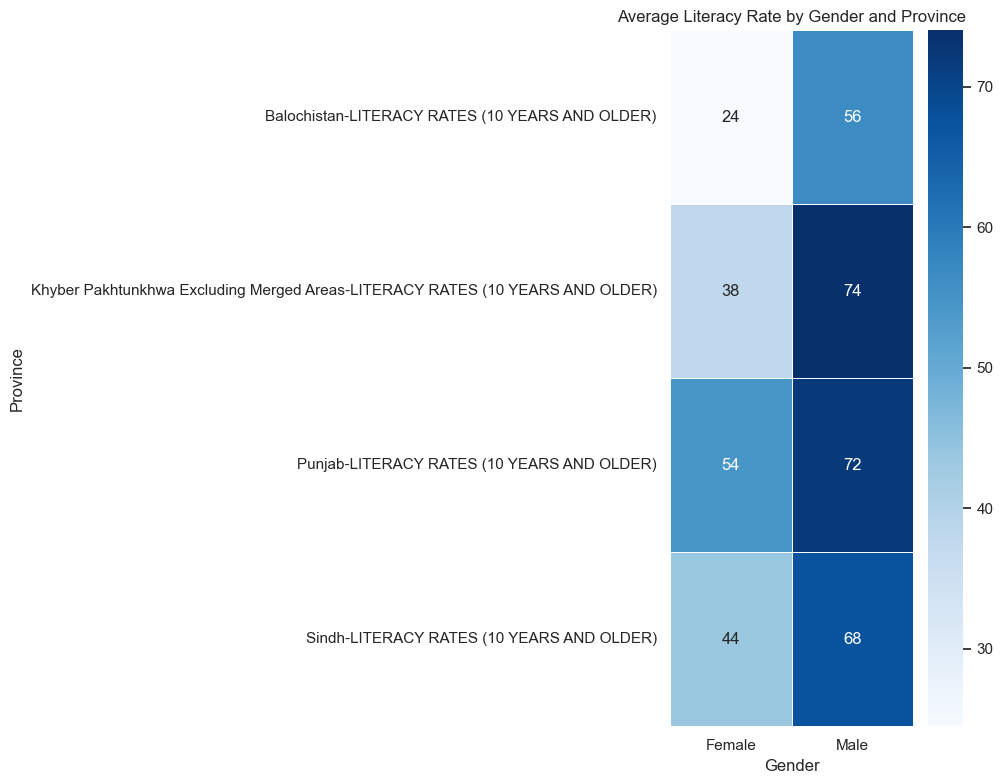

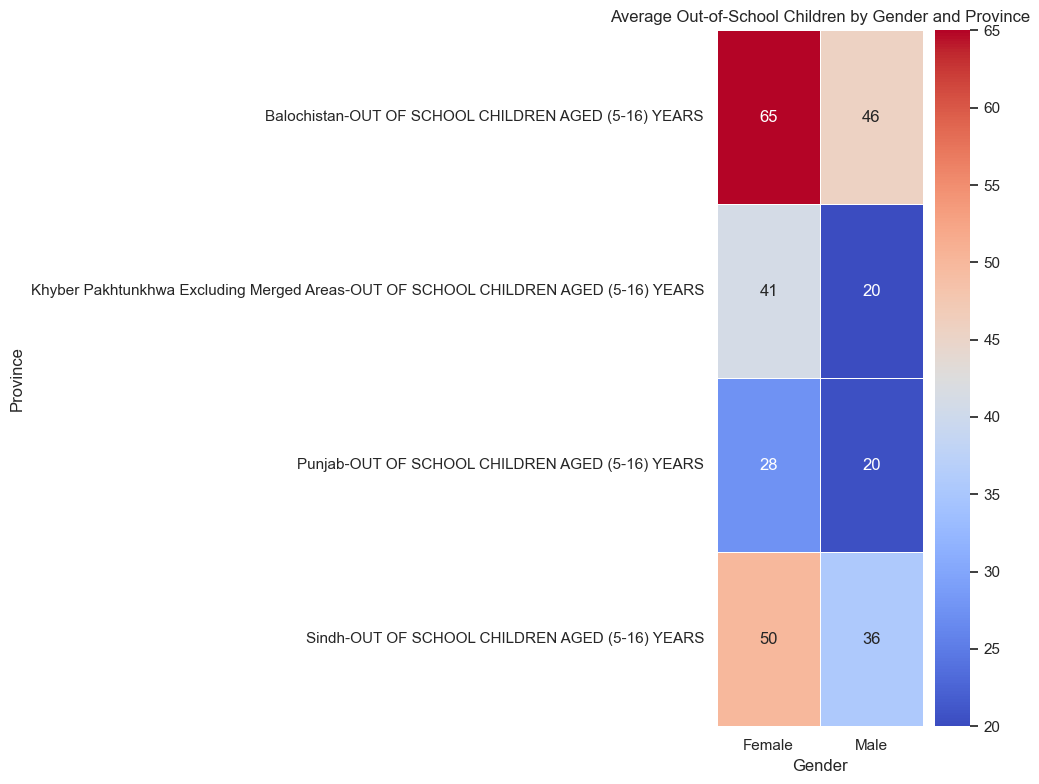

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Filter the data for the indicators of interest
indicators_of_interest = ['LITERACY RATES (10 YEARS AND OLDER)', 'OUT OF SCHOOL CHILDREN AGED (5-16) YEARS']
filtered_data = long_ind[long_ind['Indicator'].isin(indicators_of_interest)]

# STEP 2: Exclude "Total" gender and "Pakistan"
filtered_data = filtered_data[(filtered_data['Gender'] != 'Total') & (filtered_data['Province'] != 'Pakistan')]

# STEP 3: Aggregate (average) the data over gender (Male and Female) for each province and indicator
# Group by Province, Indicator, and Gender, and calculate the average for Male and Female
filtered_data_avg_gender = filtered_data.groupby(['Province', 'Indicator', 'Gender'])['Value'].mean().reset_index()

# STEP 4: Pivot the data for the heatmap (Province x Gender)
heatmap_data = filtered_data_avg_gender.pivot_table(
    index=['Province', 'Indicator'], columns='Gender', values='Value', aggfunc='mean'
)

# STEP 5: Plot the heatmap for Literacy Rates
plt.figure(figsize=(10, 8))

literacy_data = heatmap_data.loc[heatmap_data.index.get_level_values('Indicator')
                                 == 'LITERACY RATES (10 YEARS AND OLDER)']

sns.heatmap(
    literacy_data,
    annot=True,
    cmap='Blues',      # steelblue-like palette
    linewidths=0.5
)

plt.title("Average Literacy Rate by Gender and Province")
plt.xlabel("Gender")
plt.ylabel("Province")
plt.tight_layout()
plt.show()

# STEP 6: Plot the heatmap for Out-of-School Children (use the same method as above)
plt.figure(figsize=(10, 8))

oos_data = heatmap_data.loc[heatmap_data.index.get_level_values('Indicator')
                            == 'OUT OF SCHOOL CHILDREN AGED (5-16) YEARS']

sns.heatmap(
    oos_data,
    annot=True,
    cmap='coolwarm',      # steelblue-like palette
    linewidths=0.5
)

plt.title("Average Out-of-School Children by Gender and Province")
plt.xlabel("Gender")
plt.ylabel("Province")
plt.tight_layout()
plt.show()


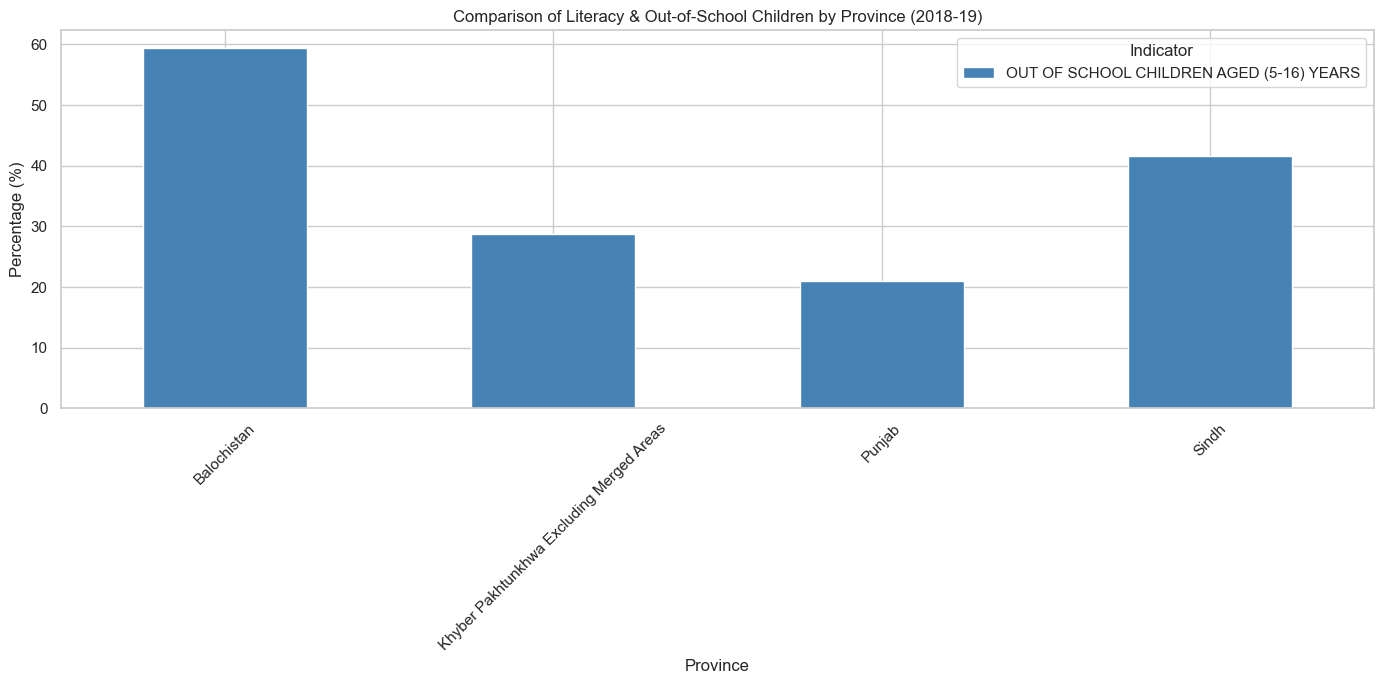

In [196]:
# Create a grouped bar chart for literacy and OOSC for 2018-19
indicators_for_comparison = ['LITERACY', 'OUT OF SCHOOL CHILDREN AGED (5-16) YEARS']

# Filter data for the indicators of interest in 2018-19
data_to_plot = long_ind[long_ind['Indicator'].isin(indicators_for_comparison) & (long_ind['Year'] == '2018-19') & (long_ind['Province'] != 'Pakistan')]

# Pivot the data for easy plotting (Province x Indicator)
data_pivot = data_to_plot.pivot_table(
    index='Province', columns='Indicator', values='Value', aggfunc='mean'
)

# Plot the grouped bar chart
data_pivot.plot(kind='bar', figsize=(14, 7), color=['steelblue', 'lightgreen'])

# Title and labels
plt.title("Comparison of Literacy & Out-of-School Children by Province (2018-19)")
plt.xlabel("Province")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


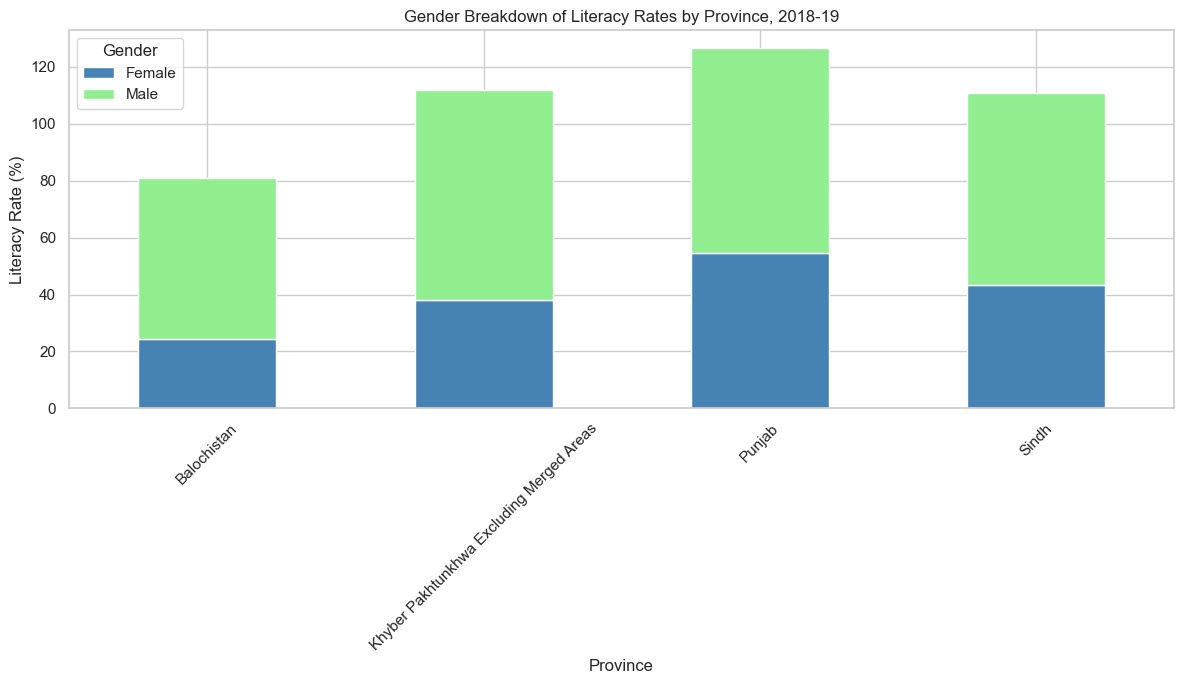

In [197]:
# Filter for literacy indicator and exclude "Total"
lit_gender = long_ind[(long_ind['Indicator'] == 'LITERACY RATES (10 YEARS AND OLDER)') & 
                      (long_ind['Gender'].isin(['Male', 'Female'])) & (long_ind['Province'] != 'Pakistan')]

# Pivot the data for a stacked bar chart (Male vs Female)
lit_gender_pivot = lit_gender.pivot_table(
    index='Province', columns='Gender', values='Value', aggfunc='mean'
)

# Plot the stacked bar chart
lit_gender_pivot.plot(kind='bar', stacked=True, figsize=(12, 7), color=['steelblue', 'lightgreen'])

plt.title("Gender Breakdown of Literacy Rates by Province, 2018-19")
plt.xlabel("Province")
plt.ylabel("Literacy Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

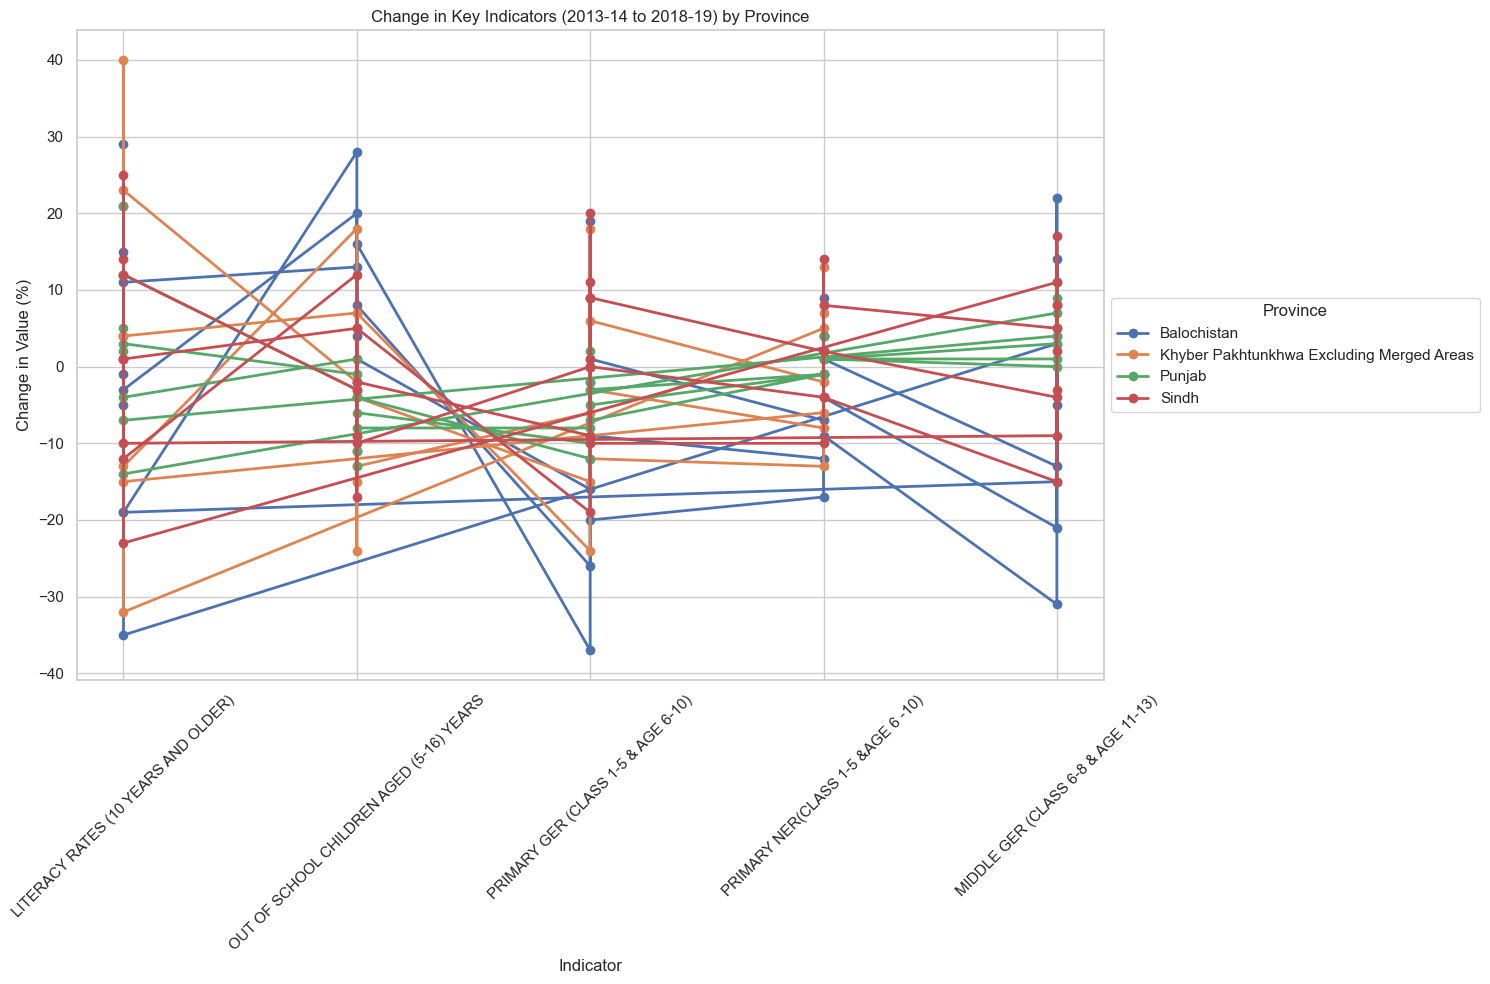

In [198]:
# Calculate the change between 2013-14 and 2018-19
change_data = long_ind[long_ind['Year'] == '2018-19'].copy()

# Merge with 2013-14 data
change_data = change_data.rename(columns={'Value': 'Value_2018_19'})
change_data_2013_14 = long_ind[long_ind['Year'] == '2013-14'].copy()
change_data_2013_14 = change_data_2013_14.rename(columns={'Value': 'Value_2013_14'})

# Merge the two dataframes
change_data = pd.merge(change_data, change_data_2013_14[['Province', 'Indicator', 'Value_2013_14']], on=['Province', 'Indicator'])

# Calculate the change
change_data['Change'] = change_data['Value_2018_19'] - change_data['Value_2013_14']

# Plot with limited provinces (for clarity)
provinces_to_plot = ['Punjab', 'Sindh', 'Khyber Pakhtunkhwa Excluding Merged Areas', 'Balochistan']  # Focus on a few

plt.figure(figsize=(15, 10))
for province, grp in change_data[change_data['Province'].isin(provinces_to_plot)].groupby('Province'):
    plt.plot(grp['Indicator'], grp['Change'], marker='o', label=province, linewidth=2)

plt.title("Change in Key Indicators (2013-14 to 2018-19) by Province")
plt.xlabel("Indicator")
plt.ylabel("Change in Value (%)")
plt.legend(title="Province", loc='center left', bbox_to_anchor=(1, 0.5))  # Legend outside
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
